# Obliquity vs. Eccentricity

Plot sky-projected stellar obliquity λ against orbital eccentricity *e*, split into
three panels by planet/star mass ratio q = M_p / M★:

| Panel | q range |
|---|---|
| Sub-Saturns | q < 3×10⁻⁴ | 
| Jupiters    | 3×10⁻⁴ ≤ q < 2×10⁻³ | 
| Super-Jupiters & BDs | q ≥ 2×10⁻³         |


- **`table1.csv`** — primary catalog (classical RM λ, e, M_p, Teff)
- **`StellarObliquityCatalog20260516.csv`** — supplementary catalog; brings λ from DT / RRM / RMR.



## Imports, style, helper functions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
import ndtest

# Times New Roman everywhere
plt.rcParams["font.family"] = "Times New Roman"
matplotlib.rcParams["mathtext.fontset"] = "custom"
matplotlib.rcParams["mathtext.rm"] = "Times New Roman"
matplotlib.rcParams["mathtext.it"] = "Times New Roman:italic"
matplotlib.rc("text.latex", preamble=r"\usepackage{sfmath}")

In [2]:
def ticksetax(ax, labelsize=15, linewidth=1.5):
    """Publication-quality tick + spine styling."""
    ax.tick_params(direction="in", which="both", width=linewidth, colors="k",
                   bottom=True, top=True, left=True, right=True, labelsize=labelsize)
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


def normalize_lambda(lam, lam_lerr, lam_uerr):
    """Fold λ into [0, 180]°; mirror the lower/upper error bars when reflected."""
    lam_out, lerr_out, uerr_out = [], [], []
    for i in range(len(lam)):
        L = lam[i] + 360 if lam[i] < 0 else lam[i]
        if 0 <= L < 180:
            lam_out.append(L);          lerr_out.append(lam_lerr[i]); uerr_out.append(lam_uerr[i])
        else:
            lam_out.append(360 - L);    lerr_out.append(lam_uerr[i]); uerr_out.append(lam_lerr[i])
    return np.array(lam_out), np.array(lerr_out), np.array(uerr_out)

## 1. Configuration

All file paths, URLs, bin edges, and plotting choices live here.

In [3]:
# ── Data sources ──────────────────────────────────────────────────────────
TABLE1_CSV         = "../table1.csv"
SO_CAT_CSV      = "StellarObliquityCatalog20260516.csv"   # supplementary catalog (DT, RRM, RMR, ...)

# ── Physical constants ────────────────────────────────────────────────────
MJUP_MSUN        = 9.5458e-4

# ── Mass-ratio bins (q = Mp / M*) ─────────────────────────────────────────
Q_SUBSAT         = (0.0,   3e-4)   # sub-Saturns (no lower bound; matches Mar25)
Q_JUPITER        = (3e-4,  2e-3)   # Jupiters
Q_MASSIVE_MIN    = 2e-3            # super-Jupiters & BDs

# ── Cuts ──────────────────────────────────────────────────────────────────
HOT_TEFF_K       = 6500            # boundary between cool (orange) and hot (red) stars
MASS_SIGMA_CUT   = 3               # require mp - N*sigma_mp > 0

# ── Plot ──────────────────────────────────────────────────────────────────
X_RANGE          = (0, 0.5999)     # eccentricity axis
RIGHT_ARROW_X    = 0.58            # x-position for ">" markers (e > 0.6)
LAMBDA_THRESH    = 40              # horizontal reference at λ = 40°
ECC_THRESH       = 0.1             # vertical reference at e = 0.1
OUTPUT_PDF       = "obliquity_vs_e.pdf"

# ── Low-SNR marker (overlay black "x" on bad RM observations) ────────────
MARK_LOW_SNR     = False            # toggle overlay
SNR_THRESH       = 3.0             # rows with rm_snr_combined < this are "bad"
                                   # NaN SNR is treated as "unknown" → no mark
# ── Plot toggles ─────────────────────────────────────────────────────────
SHOW_NAMES       = False           # annotate each point with host name
SHOW_HOTSTARS    = False            # overlay hot stars (Teff >= HOT_TEFF_K) in red


## 2. Load data sources

After this section we hold two dataframes:

- `table1`  — deduplicated Table 1 snapshot (one row per `(TIC, pl_letter)`)
- `so_cat`  — supplementary `StellarObliquityCatalog.csv` (a `pl_letter`
  column is derived from the `System` string so we can match rows back to Table 1)


In [4]:
import re

def normalize_tic(s):
    """Normalize anything to 'TIC NNNNN' string format."""
    s = str(s).strip()
    if s.upper().startswith("TIC"):
        return "TIC " + s[3:].strip()
    try:
        return f"TIC {int(s)}"
    except Exception:
        return s


def derive_pl_letter(system_name):
    """Extract planet letter from a System string used in StellarObliquityCatalog.

    Rules (in order):
      1. 'host_letter' with a single trailing lowercase letter b–f, h, i  → that letter
      2. 'host<digit><letter>' (no underscore, e.g. 'TOI-421b')          → that letter
      3. otherwise default to 'b' (single transiting planet)
    """
    s = str(system_name).strip()
    m = re.match(r"^(.+)_([b-fhi])$", s)
    if m: return m.group(2)
    m = re.match(r"^(.+\d)([b-fB])$", s)
    if m: return m.group(2).lower()
    return "b"


def projobliq_err_score(row):
    """Smaller = tighter λ measurement; used as the dedup tiebreaker."""
    e1, e2 = row.get("pl_projobliqerr1"), row.get("pl_projobliqerr2")
    if pd.isna(e1) and pd.isna(e2): return np.inf
    if pd.isna(e1): return abs(e2)
    if pd.isna(e2): return abs(e1)
    return 0.5 * (abs(e1) + abs(e2))


# ── Primary catalog (Table 1) ──────────────────────────────────────────────
# Some systems have bimodal λ posteriors → recorded as multiple rows that share
# (TIC, pl_letter) but have different peak_prob (summing to ~1). We keep the
# DOMINANT mode (highest peak_prob); ties broken by smallest projobliq error.
table1 = pd.read_csv(TABLE1_CSV, comment="#")
table1["TIC"] = table1["tic_id"].apply(normalize_tic)
table1["_err_score"] = table1.apply(projobliq_err_score, axis=1)
table1["_peak_prob"] = table1.get("peak_prob", 1.0).fillna(0.0)
table1 = (table1
                .sort_values(["_peak_prob", "_err_score"], ascending=[False, True])
                .drop_duplicates(subset=["TIC", "pl_letter"], keep="first")
                .drop(columns=["_err_score", "_peak_prob"])
                .reset_index(drop=True))
# rm_snr_combined > 3 or is nan
# SNR_THRESH = 3.0
# table1 = table1[table1["rm_snr_combined"].isna() | (table1["rm_snr_combined"] > SNR_THRESH)].reset_index(drop=True)
# ── Catalog-level partition (per system / TIC, no overlap) ────────────────
# Done right here, before any SO fallback, on raw Table-1 pl_projobliq.
# A system is "wrm" if AT LEAST ONE of its planets has a λ in Table 1.
# Use complement so multi-planet TICs with mixed status (e.g. HD 3167:
# b NaN, c -82°) are NOT double-counted.
n_sysfitted_tic    = table1["TIC"].nunique()
syswrm_unique      = set(table1.query("pl_projobliq.notna()")["TIC"])
n_sysfittedwrm_tic = len(syswrm_unique)
sysworm_unique     = set(table1["TIC"]) - syswrm_unique
n_dtornorm_tic     = len(sysworm_unique)
assert n_sysfittedwrm_tic + n_dtornorm_tic == n_sysfitted_tic, \
    f"partition broken: {n_sysfittedwrm_tic} + {n_dtornorm_tic} ≠ {n_sysfitted_tic}"

# ── Stellar Obliquity Catalog (supplementary) ─────────────────────────────
# Replaces the old SO catalog — same role but now a local CSV. Adds a
# derived pl_letter column so we can match against Table 1's (TIC, pl_letter).
so_cat = pd.read_csv(SO_CAT_CSV)
so_cat["TIC"]       = so_cat["TIC"].apply(normalize_tic)
so_cat["pl_letter"] = so_cat["System"].apply(derive_pl_letter)

print(f"Table 1     : {len(table1):>4d} rows ({n_sysfitted_tic} unique TICs)")
print(f"  nsysfitted     = {n_sysfitted_tic}  (all unique TICs)")
print(f"  nsysfittedwrm  = {n_sysfittedwrm_tic}  (≥1 planet has λ in Table 1)")
print(f"  ndtornorm      = {n_dtornorm_tic}  (no λ on any planet in Table 1)")
print(f"SO catalog  : {len(so_cat):>4d} rows ({so_cat['TIC'].nunique()} unique TICs)")


Table 1     :  258 rows (254 unique TICs)
  nsysfitted     = 254  (all unique TICs)
  nsysfittedwrm  = 233  (≥1 planet has λ in Table 1)
  ndtornorm      = 21  (no λ on any planet in Table 1)
SO catalog  :  477 rows (298 unique TICs)


## 3. Build the working table

Start from Table 1 (primary, user-curated), rename columns to the schema used downstream
(`lambdadeg`, `e`, `teff`, `q`, `mp`, …), then **fall back to the SO catalog**
for any planet whose Table 1 λ is missing.

In [5]:
# Rename Table 1 columns to the schema used by later cells
RENAME_MAP = {
    "pl_projobliq":     "lambdadeg",
    "pl_orbeccen":      "e",
    "st_teff":          "teff",
    "pl_massj":         "mp",
}
ERR_RENAME_MAP = {
    "pl_projobliqerr1": "lambdadeg_err_up",
    "pl_projobliqerr2": "lambdadeg_err_dn",
    "pl_orbeccenerr1":  "e_err_up",
    "pl_orbeccenerr2":  "e_err_dn",
    "pl_massjerr1":     "mp_err_up",
    "pl_massjerr2":     "mp_err_dn",
}

df = table1.copy()
df["tic_id"] = df["TIC"]
for src, dst in RENAME_MAP.items():
    df[dst] = df[src]
for src, dst in ERR_RENAME_MAP.items():
    df[dst] = df[src].abs()                            
df["q"]   = (df["pl_massj"] * MJUP_MSUN) / df["st_mass"]
df["snr"] = df.get("rm_snr_combined", np.nan)        # RM combined S/N (NaN = unknown)

KEEP = ["hostname", "pl_letter", "tic_id", "TIC",
        "lambdadeg", "lambdadeg_err_up", "lambdadeg_err_dn",
        "e",         "e_err_up",         "e_err_dn",
        "teff", "q", "mp", "mp_err_up", "mp_err_dn",
        "BinaryMultiStarFlag", "snr"]
working = df[KEEP].reset_index(drop=True)
print(f"Working table: {len(working)} rows")

Working table: 258 rows


In [6]:
# SO catalog fallback: refill λ wherever Table 1 has NaN.
# Track which rows got filled from SO catalog and with which Method,
# so the stats cell can split "classical-RM only" vs "line-profile (DT/RMR/RRM/...)"
filled_rows = {}      # (tic_id, pl_letter) → Method string
n_filled = 0
for i in range(len(working)):
    if (pd.notna(working.loc[i, "lambdadeg"])
        and pd.notna(working.loc[i, "lambdadeg_err_up"])
        and pd.notna(working.loc[i, "lambdadeg_err_dn"])):
        continue

    sub = so_cat[(so_cat["TIC"]       == working.loc[i, "tic_id"]) &
                 (so_cat["pl_letter"] == working.loc[i, "pl_letter"])]
    if len(sub) == 0 or pd.isna(sub["lambdadeg"].values[0]):
        continue

    method = sub["Method"].values[0] if "Method" in sub.columns else ""
    working.loc[i, "lambdadeg"]        = sub["lambdadeg"].values[0]
    working.loc[i, "lambdadeg_err_up"] = sub["lambdadeguerr"].values[0]
    working.loc[i, "lambdadeg_err_dn"] = sub["lambdadeglerr"].values[0]
    filled_rows[(working.loc[i, "tic_id"], working.loc[i, "pl_letter"])] = method
    print(f"  [{method:5s}] {working.loc[i, 'hostname']:14s} {working.loc[i, 'pl_letter']:>2s} : "
          f"λ = {sub['lambdadeg'].values[0]:+.2f} (+{sub['lambdadeguerr'].values[0]} / -{sub['lambdadeglerr'].values[0]}) ← SO catalog")
    n_filled += 1
print(f"\nFilled {n_filled} missing λ values from the SO catalog")

# Tag each row with its λ source (used by code-stats to split post-cut
# wrm/worm).  Catalog-level counts (nsysfitted / nsysfittedwrm / ndtornorm)
# are NOT recomputed here — they are set once in code-load on raw Table 1.
LINE_PROFILE_METHODS = {"DT", "RMR", "RRM", "GD", "AS", "SC", "vsini", "st_inc"}
working["lambda_src"] = working.apply(
    lambda r: filled_rows.get((r["tic_id"], r["pl_letter"]), "RM"), axis=1)
working["is_lp"] = working["lambda_src"].isin(LINE_PROFILE_METHODS)


  [DT   ] CoRoT-11        b : λ = +0.10 (+2.6 / -2.6) ← SO catalog
  [DT   ] GPX-1           b : λ = +6.90 (+10.0 / -10.0) ← SO catalog
  [RMR  ] HAT-P-49        b : λ = -97.70 (+1.8 / -1.8) ← SO catalog
  [DT   ] HAT-P-56        b : λ = +8.00 (+2.0 / -2.0) ← SO catalog
  [DT   ] HAT-P-69        b : λ = +21.20 (+4.6 / -3.6) ← SO catalog
  [DT   ] HATS-70         b : λ = +8.90 (+5.6 / -4.5) ← SO catalog
  [RMR  ] HD 3167         b : λ = -6.60 (+6.6 / -7.9) ← SO catalog
  [DT   ] HIP 33609       b : λ = +12.70 (+1.3 / -1.3) ← SO catalog
  [RMR  ] K2-105          b : λ = -81.00 (+50.0 / -47.0) ← SO catalog
  [DT   ] K2-267          b : λ = -1.48 (+0.85 / -0.85) ← SO catalog
  [RRM  ] KELT-18         b : λ = -94.80 (+0.7 / -0.7) ← SO catalog
  [DT   ] MASCARA-1       b : λ = +69.50 (+3.0 / -3.0) ← SO catalog
  [DT   ] MASCARA-4       b : λ = +250.34 (+0.14 / -0.14) ← SO catalog
  [DT   ] TOI-2109        b : λ = +1.70 (+1.7 / -1.7) ← SO catalog
  [RMR  ] TOI-421         b : λ = -35.00 (+26.

## 4. Apply cuts

1. Drop rows missing any of **λ / e / mp / M★ / Teff** (NaN in essential columns)
2. Drop **binaries** flagged by Table 1's `BinaryMultiStarFlag = 'Y'`
3. Drop planets where `mp − 3·σ_mp ≤ 0` (mass not significant)


In [7]:
def is_binary(row):
    """Table 1 BinaryMultiStarFlag: 'Y' means binary/multi-star."""
    return str(row.get("BinaryMultiStarFlag")).strip() == "Y"

cleaned = working.copy()
print(f"Start                       : {len(cleaned):>4d}")

# Step 1 — drop rows missing λ / λ_err / e / mp / M* / Teff (Mar25 convention)
need_all = ["lambdadeg", "lambdadeg_err_up", "lambdadeg_err_dn",
            "e", "e_err_up", "e_err_dn", "mp", "mp_err_dn", "teff"]
n0 = len(cleaned)
cleaned = cleaned.dropna(subset=need_all).reset_index(drop=True)
n_bad_meas = n0 - len(cleaned)
print(f"1) drop NaN (e/mp/λ/teff..) : {n0:>4d} → {len(cleaned):>4d}   ({n_bad_meas} removed)")

# Step 2 — binary
n0 = len(cleaned)
cleaned = cleaned[~cleaned.apply(is_binary, axis=1)].reset_index(drop=True)
n_bin = n0 - len(cleaned)
print(f"2) drop binaries (Table 1)  : {n0:>4d} → {len(cleaned):>4d}   ({n_bin} removed)")

# Step 3 — mass 3σ
n0 = len(cleaned)
cleaned = cleaned.query(f"mp - {MASS_SIGMA_CUT}*mp_err_dn > 0").reset_index(drop=True)
n_bad_pl_mass = n0 - len(cleaned)
print(f"3) {MASS_SIGMA_CUT}σ mass cut             : {n0:>4d} → {len(cleaned):>4d}   ({n_bad_pl_mass} removed)")

print(f"\nFinal sample size : {len(cleaned)}")


Start                       :  258
1) drop NaN (e/mp/λ/teff..) :  258 →  241   (17 removed)
2) drop binaries (Table 1)  :  241 →  151   (90 removed)
3) 3σ mass cut             :  151 →  145   (6 removed)

Final sample size : 145


## 5. Categorize by mass ratio + hot/cool

Extract arrays for plotting, fold λ to [0, 180]°, and build the six index sets:
sub-Saturn, Jupiter, super-Jupiter — each split into *all* and *hot* (Teff ≥ 6500 K).

In [8]:
pl_name  = cleaned["hostname"].values
teff     = cleaned["teff"].values
q        = cleaned["q"].values
snr      = cleaned["snr"].values            # RM combined S/N (NaN = unknown)

ecc          = cleaned["e"].values
ecc_err_low  = cleaned["e_err_dn"].values
ecc_err_high = cleaned["e_err_up"].values

# Fold λ to [0, 180]° (mirrored error bars)
lambda_, lambda_err_low, lambda_err_up = normalize_lambda(
    cleaned["lambdadeg"].values,
    cleaned["lambdadeg_err_dn"].values,
    cleaned["lambdadeg_err_up"].values,
)

def _in(q_, lo, hi=None, teff_hot=False):
    m = (q_ >= lo) & ((q_ < hi) if hi is not None else True)
    if teff_hot:
        m &= (teff >= HOT_TEFF_K)
    return np.where(m)[0]

idx_ss          = _in(q, *Q_SUBSAT)            # q < 3e-4 (no lower bound)
idx_jupiter     = _in(q, *Q_JUPITER)
idx_massive     = _in(q, Q_MASSIVE_MIN)
idx_ss_hot      = _in(q, *Q_SUBSAT,        teff_hot=True)
idx_jupiter_hot = _in(q, *Q_JUPITER,       teff_hot=True)
idx_massive_hot = _in(q, Q_MASSIVE_MIN,    teff_hot=True)

print(f"sub-Saturn : {len(idx_ss):>3d} ({len(idx_ss_hot)} hot)")
print(f"Jupiter    : {len(idx_jupiter):>3d} ({len(idx_jupiter_hot)} hot)")
print(f"super-Jupiter: {len(idx_massive):>3d} ({len(idx_massive_hot)} hot)")

sub-Saturn :  30 (1 hot)
Jupiter    :  83 (16 hot)
super-Jupiter:  32 (9 hot)


## 5b. Sub-Saturn & warm-Jupiter hot-star fraction (Teff ≥ 6500 K)

Count confirmed planets in each class and the hot-host fraction at the
Kraft break (`HOT_TEFF_K = 6500 K`). Uses `a/R_p > 110` to define warm
Jupiter (planets close enough to circularize tidally are excluded).

In [9]:
# ── Derived columns ──
key_cols = ["TIC","pl_letter","pl_orbsmax","pl_radj"]
t1_extra = table1[key_cols].drop_duplicates(["TIC","pl_letter"])
cleaned = cleaned.merge(t1_extra, left_on=["tic_id","pl_letter"],
                        right_on=["TIC","pl_letter"], how="left", suffixes=("","_t1"))
cleaned["a_Rp"] = cleaned["pl_orbsmax"] * 215.032 / (cleaned["pl_radj"] * 0.10049)

# lambda_src / is_lp were attached to `working` in code-fallback and survive
# the cuts in code-cuts, so they are already present on `cleaned`.
is_lp = cleaned["is_lp"]
is_rm = ~is_lp

# ── Bin masks ──
q = cleaned["q"].values
idx_ss  = (q >= Q_SUBSAT[0])    & (q < Q_SUBSAT[1])
idx_jup = (q >= Q_JUPITER[0])   & (q < Q_JUPITER[1])
idx_mj  = (q >= Q_MASSIVE_MIN)

# ── Counts ──
# Catalog-level (per-TIC, computed in code-fallback so row/TIC are not mixed)
n_sysfitted    = n_sysfitted_tic
n_dtornorm     = n_dtornorm_tic
n_sysfittedwrm = n_sysfittedwrm_tic

# Post-cut sample (row-level, since one row = one (TIC, pl_letter))
n_sysusedforanalysis = len(cleaned)
n_ss   = int(idx_ss.sum())
n_jup  = int(idx_jup.sum())
n_mj   = int(idx_mj.sum())
# n_bad_pl_mass and n_bin come from code-cuts
n_sysusedforanalysiswrm  = int(is_rm.sum())
n_ss_wrm  = int((is_rm & idx_ss).sum())
n_jup_wrm = int((is_rm & idx_jup).sum())
n_mj_wrm  = int((is_rm & idx_mj).sum())
n_sysusedforanalysisworm = int(is_lp.sum())
n_ss_worm  = int((is_lp & idx_ss).sum())
n_jup_worm = int((is_lp & idx_jup).sum())
n_mj_worm  = int((is_lp & idx_mj).sum())

# ── Hot fractions ──
def hot_frac(mask):
    sub = cleaned[mask]
    n = len(sub); nh = int((sub["teff"] >= HOT_TEFF_K).sum())
    return n, nh, (100.0*nh/n if n else 0.0)
(_n_ss,_h_ss,_p_ss)         = hot_frac(idx_ss)
(_n_jup,_h_jup,_p_jup)      = hot_frac(idx_jup)
(_n_mj,_h_mj,_p_mj)         = hot_frac(idx_mj)


# ── Composition summary ──
print(f"\n=== Sample composition (HOT_TEFF_K = {HOT_TEFF_K} K, a/R_p > 110 = warm) ===")
print(f"  {'class':30s}  {'N':>4s}  {'hot':>4s}  {'frac':>6s}")
print('  '+'-'*52)
print(f"  {'Sub-Saturns':30s}  {_n_ss:>4d}  {_h_ss:>4d}  {_p_ss:>5.1f}%")
print(f"  {'Jupiters (all)':30s}  {_n_jup:>4d}  {_h_jup:>4d}  {_p_jup:>5.1f}%")
print(f"  {'Super-Jupiters & BDs':30s}  {_n_mj:>4d}  {_h_mj:>4d}  {_p_mj:>5.1f}%")

print(f"\n=== Classical RM vs Line-profile (DT/RMR/RRM/...) ===")
print(f"  {'class':30s}  {'all':>5s}  {'RM':>5s}  {'LP':>5s}")
print('  '+'-'*52)
print(f"  {'Sub-Saturns':30s}  {n_ss:>5d}  {n_ss_wrm:>5d}  {n_ss_worm:>5d}")
print(f"  {'Jupiters':30s}  {n_jup:>5d}  {n_jup_wrm:>5d}  {n_jup_worm:>5d}")
print(f"  {'Super-Jupiters':30s}  {n_mj:>5d}  {n_mj_wrm:>5d}  {n_mj_worm:>5d}")
print(f"  {'TOTAL':30s}  {n_sysusedforanalysis:>5d}  {n_sysusedforanalysiswrm:>5d}  {n_sysusedforanalysisworm:>5d}")

# ── LaTeX block (same order as paper main.tex) ──
print(f"\n{'='*50}")
print(r"% \newcommand block (paste into main.tex)")
print(r"\newcommand{\nsysfitted}{"               + f"{n_sysfitted}"              + "}")
print(r"\newcommand{\nsysfittedwrm}{"            + f"{n_sysfittedwrm}"           + "}")
print(r"\newcommand{\ndtornorm}{"                + f"{n_dtornorm}"               + "}")
print(r"\newcommand{\nsysusedforanalysis}{"      + f"{n_sysusedforanalysis}"     + "}")
print(r"\newcommand{\nss}{"                      + f"{n_ss}"                     + "}")
print(r"\newcommand{\njup}{"                     + f"{n_jup}"                    + "}")
print(r"\newcommand{\nmassive}{"                 + f"{n_mj}"                     + "}")
print(r"\newcommand{\nbadplmass}{"               + f"{n_bad_pl_mass}"            + "}")
print(r"\newcommand{\nbin}{"                     + f"{n_bin}"                    + "}")
print(r"\newcommand{\nsysusedforanalysiswrm}{"   + f"{n_sysusedforanalysiswrm}"  + "}")
print(r"\newcommand{\nsswrm}{"                   + f"{n_ss_wrm}"                 + "}")
print(r"\newcommand{\njwrm}{"                    + f"{n_jup_wrm}"                + "}")
print(r"\newcommand{\nmjwrm}{"                   + f"{n_mj_wrm}"                 + "}")
print(r"\newcommand{\nsysusedforanalysisworm}{"  + f"{n_sysusedforanalysisworm}" + "}")
print(r"\newcommand{\nssworm}{"                  + f"{n_ss_worm}"                + "}")
print(r"\newcommand{\njworm}{"                   + f"{n_jup_worm}"               + "}")
print(r"\newcommand{\nmjworm}{"                  + f"{n_mj_worm}"                + "}")




=== Sample composition (HOT_TEFF_K = 6500 K, a/R_p > 110 = warm) ===
  class                              N   hot    frac
  ----------------------------------------------------
  Sub-Saturns                       30     1    3.3%
  Jupiters (all)                    83    16   19.3%
  Super-Jupiters & BDs              32     9   28.1%

=== Classical RM vs Line-profile (DT/RMR/RRM/...) ===
  class                             all     RM     LP
  ----------------------------------------------------
  Sub-Saturns                        30     26      4
  Jupiters                           83     81      2
  Super-Jupiters                     32     28      4
  TOTAL                             145    135     10

% \newcommand block (paste into main.tex)
\newcommand{\nsysfitted}{254}
\newcommand{\nsysfittedwrm}{233}
\newcommand{\ndtornorm}{21}
\newcommand{\nsysusedforanalysis}{145}
\newcommand{\nss}{30}
\newcommand{\njup}{83}
\newcommand{\nmassive}{32}
\newcommand{\nbadplmass}{6}
\newcomman

## 6. Plot

KDE contour (blue) + scatter (orange / red for hot stars) + asymmetric error
bars. Points with e > 0.6 are placed at `RIGHT_ARROW_X` and drawn as `>` arrows.

**Optional overlay**: if `MARK_LOW_SNR = True`, observations with
`rm_snr_combined < SNR_THRESH` get a black `×` on top of the marker —
useful for visually downweighting noisy RM/DT detections.


In [10]:
def truncate_colormap(cmap, vmin=0.0, vmax=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        "truncated", cmap(np.linspace(vmin, vmax, n)))


def power_colormap(name, gamma=2.0, n=256):
    base = plt.get_cmap(name, n)
    return LinearSegmentedColormap.from_list(
        f"{name}_g{gamma}", base(np.linspace(0, 1, n) ** gamma))


def transparent_then_color(name, transparent_ratio=0.1, fade_ratio=0.1,
                           vmin=0.0, vmax=1.0, n=256):
    """Build a colormap that fades from transparent-white into a base palette."""
    base = plt.get_cmap(name, n)(np.linspace(0, 1, n))
    nt   = int(n * transparent_ratio)
    nf   = int(n * fade_ratio)
    transparent = np.tile([1, 1, 1, 0], (nt, 1))
    fade        = (np.array([1, 1, 1, 0]) * (1 - np.linspace(0, 1, nf)[:, None])
                   + base[:nf] * np.linspace(0, 1, nf)[:, None])
    colors = np.vstack([transparent, fade, base[nf:]])
    return truncate_colormap(LinearSegmentedColormap.from_list(f"S{name}", colors),
                             vmin, vmax)


CMAP_BLUES     = transparent_then_color("Blues",  0.01, 0.01, 0.0, 1.0)
CMAP_BLUES_LIT = transparent_then_color("Blues",  0.10, 0.05, 0.0, 0.5)
CMAP_BLUES_GAM = power_colormap("Blues", gamma=1)

In [11]:
def plot_panel(ax, idx, idx_hot, title, contour_alpha=0.7):
    """One panel of the obliquity-vs-eccentricity figure."""
    x      = ecc[idx];           y      = lambda_[idx]
    x_lo   = ecc_err_low[idx];   x_hi   = ecc_err_high[idx]
    y_lo   = lambda_err_low[idx]; y_hi  = lambda_err_up[idx]

    # KDE contour
    X, Y = np.meshgrid(np.linspace(*X_RANGE, 1000),
                       np.linspace(0, 180,   1000))
    kde  = gaussian_kde(np.vstack([x, y]))(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    cmap = CMAP_BLUES_LIT if "Sub" in title else CMAP_BLUES_GAM
    img  = kde if "Sub" in title else kde
    ax.imshow(img if "Sub" not in title else np.ma.masked_where(kde < 1e-5, kde),
              extent=[*X_RANGE, 0, 180], origin="lower",
              cmap=(CMAP_BLUES if "Sub" in title else cmap),
              alpha=contour_alpha, aspect="auto", zorder=2)

    # Error bars (excluding e > 0.6 — those go to right-arrow strip)
    in_range = x <= 0.6
    ax.errorbar(x[in_range], y[in_range],
                xerr=[x_lo[in_range], x_hi[in_range]],
                yerr=[y_lo[in_range], y_hi[in_range]],
                fmt="o", color="k", alpha=0.3, capsize=2, elinewidth=1, ms=0, zorder=3)

    # Scatter (cool then hot on top)
    ax.scatter(x[in_range], y[in_range], s=25, color="orange", alpha=0.9,
               edgecolor="k", linewidth=0.5, marker="o", zorder=4, label="Cool")
    if SHOW_HOTSTARS:
        ax.scatter(ecc[idx_hot], lambda_[idx_hot], s=25, color="#fc3d20",
                   alpha=0.9, edgecolor="k", linewidth=0.5, marker="o",
                   zorder=400, label="Hot (Teff ≥ %d K)" % HOT_TEFF_K)
        print(f"  {title}: {len(x)} total, {len(idx_hot)} hot stars (Teff ≥ {HOT_TEFF_K} K)")

    # Optional overlay: black "x" on low-SNR (bad) observations
    if MARK_LOW_SNR:
        snr_sub = snr[idx]
        bad = np.isfinite(snr_sub) & (snr_sub < SNR_THRESH)
        if bad.any():
            ax.scatter(x[bad & in_range], y[bad & in_range],
                       s=70, c="k", marker="x", linewidth=1.5,
                       zorder=500, label=f"SNR < {SNR_THRESH}")

    # Right-arrow strip for e > 0.6
    over = x > 0.6
    if over.any():
        xa = np.full(over.sum(), RIGHT_ARROW_X)
        ax.errorbar(xa, y[over],
                    xerr=[x_lo[over], x_hi[over]],
                    yerr=[y_lo[over], y_hi[over]],
                    fmt=">", color="k", alpha=0.3, capsize=2, elinewidth=1, ms=0, zorder=3)
        ax.scatter(xa, y[over], s=40, color="orange", alpha=0.9,
                   edgecolor="k", linewidth=0.5, marker=">", zorder=4)
        if MARK_LOW_SNR:
            snr_over = snr[idx][over]
            bad_o = np.isfinite(snr_over) & (snr_over < SNR_THRESH)
            if bad_o.any():
                ax.scatter(xa[bad_o], y[over][bad_o],
                           s=70, c="k", marker="x", linewidth=1.5, zorder=500)

    ax.set_xlim(*X_RANGE)
    ax.set_ylim(0.0001, 180)
    ax.text(0.98, 0.87, title, fontsize=12, weight="bold",
            ha="right", va="center", transform=ax.transAxes)
    ax.axvline(x=ECC_THRESH,    color="k", linestyle="--", alpha=0.4)
    ax.axhline(y=LAMBDA_THRESH, color="k", linestyle="--", alpha=0.4)


PANEL_TITLES = [
    ("Sub-Saturns",   r"$M_p/M_*<3\times10^{-4}$", idx_ss,      idx_ss_hot,      0.5),
    ("Jupiters",      r"$3\times10^{-4} < M_p/M_*\leq 2\times10^{-3}$", idx_jupiter, idx_jupiter_hot, 0.7),
    ("Super Jupiters & Brown Dwarfs",
                      r"$2\times10^{-3} < M_p/M_*$",                 idx_massive, idx_massive_hot, 0.6),
]

saved → obliquity_vs_e.pdf


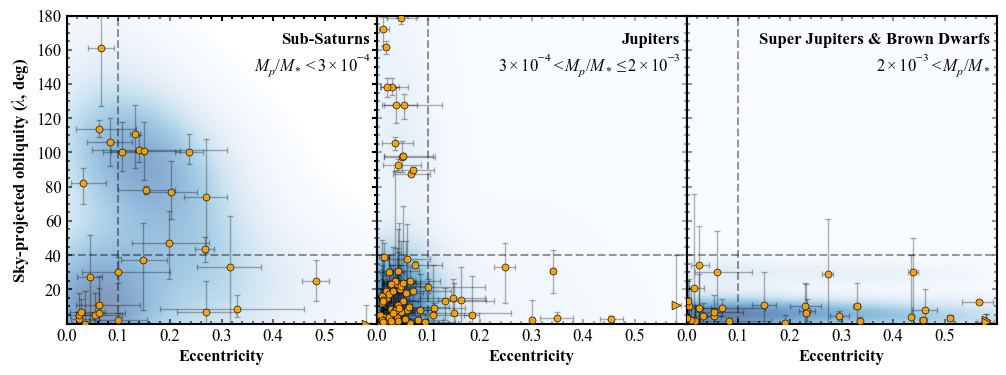

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
plt.subplots_adjust(wspace=0.0)

for ax, (name, math, idx, idx_hot, alpha) in zip(axes, PANEL_TITLES):
    plot_panel(ax, idx, idx_hot, f"{name}\n {math}", contour_alpha=alpha)
    ax.set_xlabel("Eccentricity", fontsize=12, weight="bold")
    ticksetax(ax, labelsize=12)

axes[0].set_ylabel(r"Sky-projected obliquity ($\lambda$, deg)", fontsize=12, weight="bold")

if SHOW_NAMES:
    for ax, idx in zip(axes, [idx_ss, idx_jupiter, idx_massive]):
        for i in idx:
            ax.text(ecc[i], lambda_[i], pl_name[i], fontsize=10)

plt.savefig(OUTPUT_PDF, bbox_inches="tight", dpi=600)
print(f"saved → {OUTPUT_PDF}")